# Main results

The unit-level model with ethnicity-by-year fixed effects and the within-pair regression are the same estimator, so their coefficients have to match.

**Expected**

| specification | coefficient |
|---|---|
| unit and year FE | -0.2163 |
| ethnicity-by-year FE | -0.2096 |
| within-pair gap | -0.2096 |
| within-pair, year FE | -0.1656 |
| plus common trend | -0.0703 |
| plus group trends | -0.0424 |

In [1]:
import sys
sys.path.append("../src")

import pandas as pd
import matplotlib.pyplot as plt

import config
import estimation

import figures
figures.setup()

In [2]:
panel_df = pd.read_csv(config.WORK / 'panel_narrow.csv')
pair = pd.read_csv(config.WORK / 'pair_panel.csv')
specs = estimation.main_specifications(panel_df, pair)
specs.round(4)

,spec,coef,se,p,n
0,unit and year FE,-0.2163,0.1541,0.1604,726
1,ethnicity-by-year FE,-0.2096,0.1911,0.2728,726
2,within-pair gap,-0.2096,0.1350,0.1206,363
3,"within-pair gap, year FE",-0.1656,0.2938,0.5729,363
4,plus common linear trend,-0.0703,0.2156,0.7443,363
5,plus group-specific trends,-0.0424,0.2433,0.8618,363


In [3]:
# the two identical specifications must agree
a = specs.loc[specs['spec'] == 'ethnicity-by-year FE', 'coef'].iloc[0]
b = specs.loc[specs['spec'] == 'within-pair gap', 'coef'].iloc[0]
diff = abs(a - b)
print(f"difference between the two identical specifications: {diff:.3e}")
assert diff < 1e-4, f"specifications disagree by {diff:.4f}"

difference between the two identical specifications: 1.976e-14


In [4]:
estimation.cohort_effects(pair).round(4)

,cohort,coef,se,p,groups
0,1993,0.2820,0.5159,0.5847,2
1,1996,-0.1290,0.1075,0.2298,3
2,1998,-0.2619,0.2320,0.2590,5
3,2003,-0.2804,NaN,NaN,1


{'F': 0.5840302775960984, 'p': 0.6814626672313044, 'restrictions': 4}
saved event_study.pdf and event_study.png


,rel_year,coef,lo,hi,groups
0,-5,0.2451,-0.4779,0.9680,6
1,-4,-0.4006,-1.5661,0.7650,9
2,-3,0.1276,-0.4977,0.7528,9
3,-2,-0.0021,-0.6660,0.6619,9
4,-1,0.0000,0.0000,0.0000,11
5,0,-0.0457,-0.7742,0.6828,11
6,1,-0.0653,-0.7852,0.6546,11
7,2,-0.0595,-0.9830,0.8640,11
8,3,0.0413,-0.6178,0.7004,11
9,4,-0.0635,-0.7264,0.5993,11


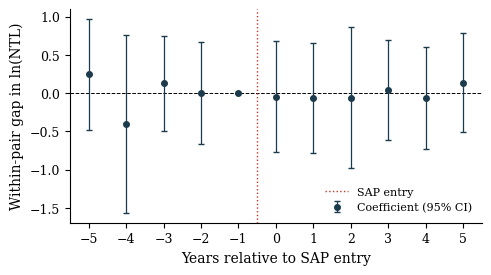

In [5]:
coefs, model, terms = estimation.event_study(pair)
print(estimation.pretrend_test(model, terms))
figures.event_study(coefs)
coefs.round(4)

saved sample_map.pdf and sample_map.png


(<Figure size 480x480 with 1 Axes>, <Axes: >)

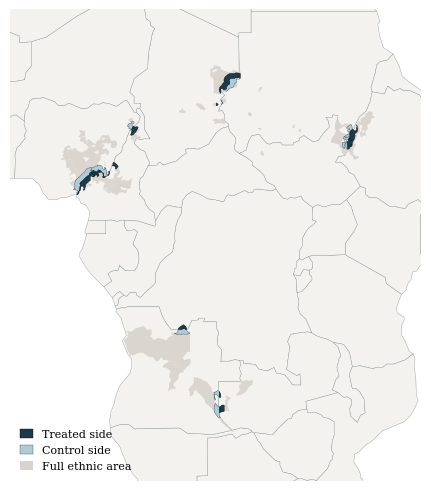

In [6]:
import geopandas as gpd

# which side of each pair is the treated one
buffers = gpd.read_file(config.WORK / "buffers.gpkg")
sides = pair[["G1ID", "country_treated"]].drop_duplicates()
buffers = buffers.merge(sides, on="G1ID", how="inner")
buffers["treated"] = (buffers["FIPS_CNTRY"] == buffers["country_treated"]).astype(int)

# background: Africa, plus the full ethnic territories for context
world = gpd.read_file(config.COUNTRIES_110M)
africa = world[world["CONTINENT"] == "Africa"]

greg = gpd.read_file(config.GREG_SHP)
areas = greg[greg["G1ID"].isin(pair["G1ID"].unique())]

figures.sample_map(buffers, africa, ethnic_areas=areas)

saved event_time_bins.pdf and event_time_bins.png


,bin,coef,lo,hi,p,groups,n
0,t<=-6,0.3212,0.0034,0.6390,0.0476,6,11
1,-5..-3,-0.0066,-0.3529,0.3396,0.9700,9,24
2,-2..-1,0.0000,0.0000,0.0000,NaN,11,20
3,0..2,-0.0807,-0.5462,0.3848,0.7340,11,33
4,3..5,0.0142,-0.3457,0.3740,0.9385,11,33
5,6..10,-0.1156,-0.5247,0.2935,0.5796,11,55
6,11..15,-0.1911,-0.6619,0.2798,0.4264,11,55
7,t>15,-0.2227,-0.8000,0.3547,0.4497,11,132


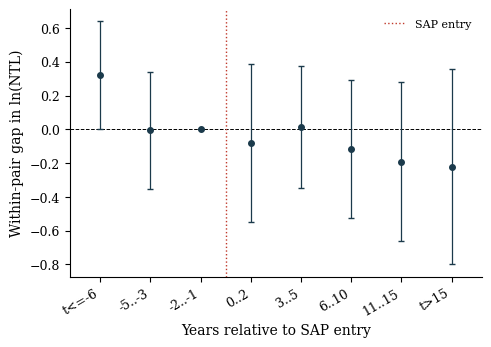

In [7]:
bins, bins_model = estimation.event_time_bins(pair)
figures.event_time_bins(bins)
bins.round(4)

In [8]:
estimation.cohort_effects(pair).to_csv(config.OUT / "cohort_effects.csv", index=False)
bins.to_csv(config.OUT / "event_time_bins.csv", index=False)
specs.to_csv(config.OUT / "main_specifications.csv", index=False)
coefs.to_csv(config.OUT / "event_study.csv", index=False)
print("saved")

saved
